Generated Dataset:
          X          Y  Class
0 -1.254599   1.665162      1
1  4.507143  19.011138      0
2  2.319939   9.670007      1
3  0.986585   2.241188      1
4 -3.439814   7.782032      0

Dataset Shape: (300, 3)


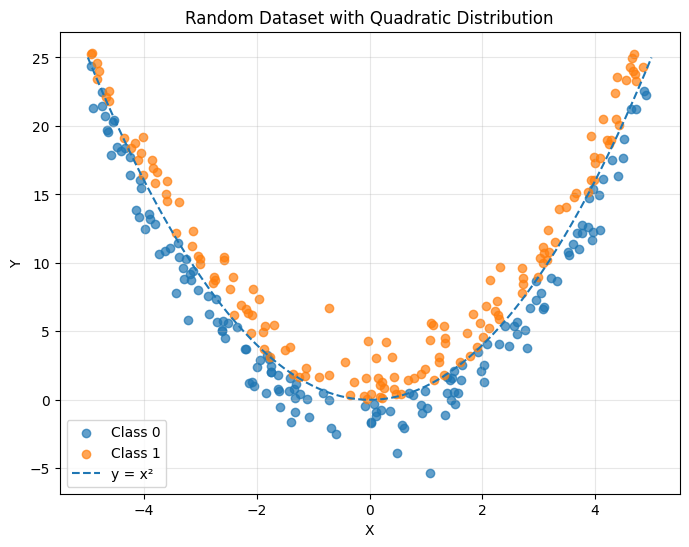

Input Variables:
          X          Y
0 -1.254599   1.665162
1  4.507143  19.011138
2  2.319939   9.670007
3  0.986585   2.241188
4 -3.439814   7.782032

Target Variable:
0    1
1    0
2    1
3    1
4    0
Name: Class, dtype: int64

Training Samples: 240
Testing Samples: 60

SVM model trained successfully.

Predictions:
[0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0]

Accuracy: 0.4666666666666667
Accuracy Percentage: 46.666666666666664 %

Confusion Matrix:
[[22  8]
 [24  6]]


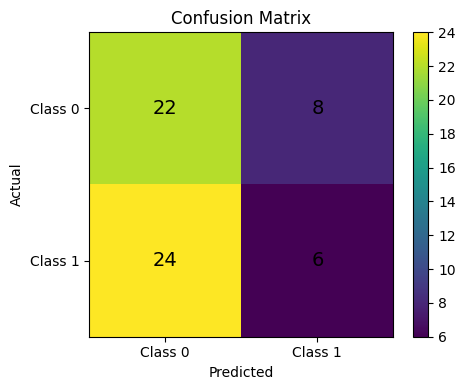


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.48      0.73      0.58        30
     Class 1       0.43      0.20      0.27        30

    accuracy                           0.47        60
   macro avg       0.45      0.47      0.43        60
weighted avg       0.45      0.47      0.43        60



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


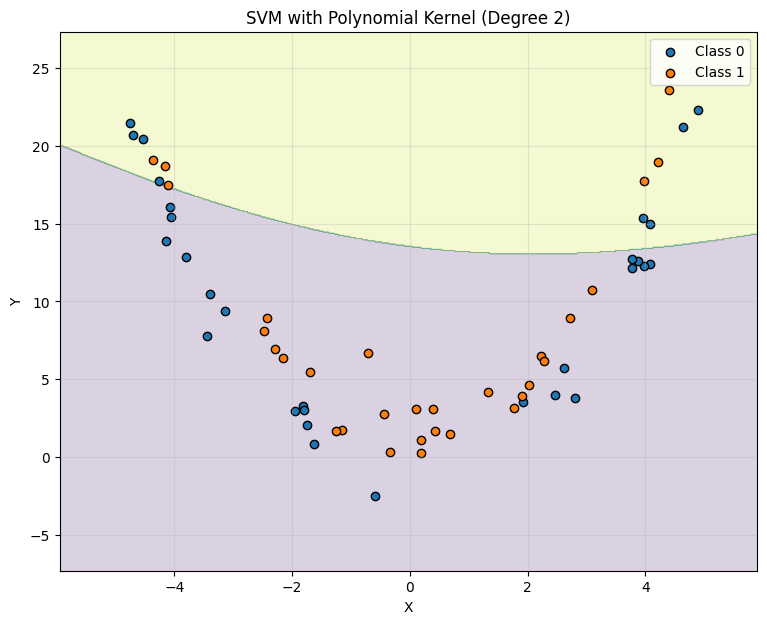


Number of Support Vectors:
[ 99 100]

Total Support Vectors:
199

New Data Point:
     X    Y
0  2.0  5.0

Predicted Class:
Class 0

SVM classification was successfully performed on a randomly generated
dataset following a quadratic distribution.
A polynomial kernel of degree 2 was used to model the nonlinear
quadratic relationship between the variables.
The model was evaluated using accuracy, confusion matrix,
classification report, and the SVM decision boundary.


In [1]:
# 1. Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Generate random dataset following a quadratic distribution

np.random.seed(42)

n_samples = 300

X = np.random.uniform(-5, 5, n_samples)

noise = np.random.normal(0, 2, n_samples)

Y = X**2 + noise

labels = (Y > X**2).astype(int)

df = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Class': labels
})

print("Generated Dataset:")
print(df.head())

print("\nDataset Shape:", df.shape)


# 3. Visualize the generated dataset

plt.figure(figsize=(8, 6))

plt.scatter(
    df[df['Class'] == 0]['X'],
    df[df['Class'] == 0]['Y'],
    label='Class 0',
    alpha=0.7
)

plt.scatter(
    df[df['Class'] == 1]['X'],
    df[df['Class'] == 1]['Y'],
    label='Class 1',
    alpha=0.7
)

x_curve = np.linspace(-5, 5, 300)
plt.plot(
    x_curve,
    x_curve**2,
    linestyle='--',
    label='y = x²'
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Random Dataset with Quadratic Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 4. Define input and target variables

X_data = df[['X', 'Y']]
y_data = df['Class']

print("Input Variables:")
print(X_data.head())

print("\nTarget Variable:")
print(y_data.head())


# 5. Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.20,
    random_state=42,
    stratify=y_data
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# 6. Create and train SVM model

model = SVC(
    kernel='poly',
    degree=2,
    C=1,
    gamma='scale'
)

model.fit(X_train, y_train)

print("\nSVM model trained successfully.")


# 7. Make predictions

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred[:20])


# 8. Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# 9. Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# 10. Display classification report

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Class 0', 'Class 1']
    )
)


# 11. Visualize SVM decision boundary

x_min = X_data['X'].min() - 1
x_max = X_data['X'].max() + 1
y_min = X_data['Y'].min() - 2
y_max = X_data['Y'].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.scatter(
    X_test[y_test == 0]['X'],
    X_test[y_test == 0]['Y'],
    label='Class 0',
    edgecolors='black'
)

plt.scatter(
    X_test[y_test == 1]['X'],
    X_test[y_test == 1]['Y'],
    label='Class 1',
    edgecolors='black'
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('SVM with Polynomial Kernel (Degree 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 12. Display support vectors

print("\nNumber of Support Vectors:")
print(model.n_support_)

print("\nTotal Support Vectors:")
print(len(model.support_))


# 13. Predict a new data point

new_data = pd.DataFrame({
    'X': [2.0],
    'Y': [5.0]
})

new_prediction = model.predict(new_data)

print("\nNew Data Point:")
print(new_data)

print("\nPredicted Class:")

if new_prediction[0] == 0:
    print("Class 0")
else:
    print("Class 1")


# 14. Conclusion

print("\nSVM classification was successfully performed on a randomly generated")
print("dataset following a quadratic distribution.")
print("A polynomial kernel of degree 2 was used to model the nonlinear")
print("quadratic relationship between the variables.")
print("The model was evaluated using accuracy, confusion matrix,")
print("classification report, and the SVM decision boundary.")